# Day 4: DINOv1/CLIP が K=11 で失敗する原因分析

## 背景

K=5→K=11 でスロット数を増やしたところ、バックボーンごとに劇的に異なる結果が出た：

| Backbone | K=5 FG-ARI | K=11 FG-ARI | 変化 |
|---|---|---|---|
| **DINOv2** | 0.155 | **0.470** | +0.315 ★ 大幅改善 |
| DINOv1 | 0.176 | 0.131 | -0.045 悪化 |
| CLIP | 0.047 | 0.110 | +0.063 微改善 |

**疑問**: なぜ同じアーキテクチャ（Slot Attention + 同じデコーダ）で、バックボーンだけ変えるとこれほど差が出るのか？

## このノートブックの構成

1. **§1 準備**: モデルとデータの読み込み
2. **§2 バックボーン特徴量の可視化**: 3つのバックボーンが「何を見ているか」を直接比較
3. **§3 投影（Projection）の分析**: 384次元→64次元に圧縮する際に何が失われるか
4. **§4 Slot Attentionの出力分析**: マスクの質を定量評価
5. **§5 再構成品質とTrivial Mean-Fill基準**: モデルが本当に学習しているか判定
6. **§6 結論**: Goldilocks特性の説明

## §1 準備

### 用語の事前説明

このノートブックで使う用語を先に定義する：

- **バックボーン（Backbone）**: 画像から特徴量を抽出する事前学習済みのViTモデル。DINOv2/DINOv1/CLIPの3種類を比較する
- **特徴量（Feature）**: バックボーンが出力するベクトル。画像の各パッチ（16×16ピクセル）ごとに384次元のベクトルが1つ出る。224×224画像なら16×16=256個のパッチ → 256個の384次元ベクトル
- **投影（Projection）**: 384次元の特徴量を、Slot Attentionが処理できる64次元に圧縮するMLPネットワーク。`LayerNorm → Linear(384→384) → ReLU → Linear(384→64)` で構成
- **Slot Attention**: 圧縮された特徴量を受け取り、K個のスロット（物体表現）に分解する注意機構
- **再構成（Reconstruction）**: スロットからデコーダを通して元の384次元特徴量を復元すること
- **マスク（Mask）**: 各スロットが画像のどの領域を担当するかを示す確率マップ（16×16の空間）

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from sklearn.decomposition import PCA
import sys, os, warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
from savi_dinosaur import SAViDinosaur

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# 3つのK=11モデルを読み込む
configs = [
    ('DINOv2', '../checkpoints/dinov2_K11/dinov2_vits14/best_model.pt', 'dinov2_vits14'),
    ('DINOv1', '../checkpoints/dinov1_K11/dino_vits16/best_model.pt', 'dino_vits16'),
    ('CLIP',   '../checkpoints/clip_K11/clip_vitb16/best_model.pt', 'clip_vitb16'),
]

models = {}
for name, ckpt_path, backbone in configs:
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    model = SAViDinosaur(num_slots=11, backbone=backbone, image_size=224)
    model.load_state_dict(ckpt['model_state_dict'], strict=False)
    model = model.to(device).eval()
    models[name] = model
    print(f"  ✓ {name}: epoch={ckpt['epoch']}, loss={ckpt['loss']:.4f}")

# データ読み込み（MOVi-A v2、最初の30シーン）
data_dir = '../data/movi_a_v2'
files = sorted([f for f in os.listdir(data_dir) if f.endswith('.pt') and f.startswith('scene_')])
print(f"\nDataset: {len(files)} scenes available, using first 30 for analysis")

Device: cuda
Loading dinov2_vits14 model (image_size=224, spatial=16×16)...


Using cache found in /home/menserve/.cache/torch/hub/facebookresearch_dinov2_main


  ✓ DINOv2: epoch=195, loss=0.9074
Loading dino_vits16 model (image_size=224, spatial=14×14)...


Using cache found in /home/menserve/.cache/torch/hub/facebookresearch_dino_main


  ✓ DINOv1: epoch=199, loss=0.2691
Loading clip_vitb16 model (image_size=224, spatial=14×14)...
  ✓ CLIP: epoch=4, loss=0.0575

Dataset: 300 scenes available, using first 30 for analysis


## §2 バックボーン特徴量の性質

まず「各バックボーンが画像からどんな特徴量を出力するか」を調べる。

### 検証の目的
Slot Attentionは入力された特徴量をもとに「どのパッチがどのスロット（物体）に属するか」を競合的に決める。つまり、**パッチ間で特徴量が十分に異なっていなければ、スロットはパッチを区別できない**。

そこで以下の指標を計測する：
- **コサイン類似度**: パッチ間の類似度。1.0に近いほど「全パッチが同じ方向を向いている」（=区別不可能）
- **空間分散**: 各次元の分散の平均。高いほど「パッチごとに値がばらつく」
- **PCA次元数**: 分散の90%を説明するのに必要な主成分数。多いほど「情報が多次元に分散」
- **ノルム（大きさ）**: 特徴量ベクトルの長さ。バックボーンによって大きく異なる

In [2]:
# === §2.1 バックボーン生特徴量の統計 (20シーン平均) ===
raw_stats = {name: {'cosine': [], 'spatial_var': [], 'norm_mean': [], 'norm_std': []} 
             for name in models}

for fname in files[:20]:
    data = torch.load(os.path.join(data_dir, fname), weights_only=False)
    video = data['video'][:1]
    img = F.interpolate(video, size=(224, 224), mode='bilinear', align_corners=False).to(device)
    
    for bname, model in models.items():
        with torch.no_grad():
            feat = model.feature_extractor(img)  # (1, 384, H, W)
        b, c, h, w = feat.shape
        feat_flat = feat.permute(0, 2, 3, 1).reshape(b, -1, c)[0].cpu().numpy()  # (N, 384)
        
        # コサイン類似度（全パッチ対のサンプリング）
        idx = np.random.choice(feat_flat.shape[0], min(50, feat_flat.shape[0]), replace=False)
        sim = cos_sim(feat_flat[idx], feat_flat[idx])
        upper = sim[np.triu_indices(len(idx), k=1)]
        
        # ノルム
        norms = np.linalg.norm(feat_flat, axis=1)
        
        raw_stats[bname]['cosine'].append(upper.mean())
        raw_stats[bname]['spatial_var'].append(np.var(feat_flat, axis=0).mean())
        raw_stats[bname]['norm_mean'].append(norms.mean())
        raw_stats[bname]['norm_std'].append(norms.std())

# PCA（1シーン分で計算）
data0 = torch.load(os.path.join(data_dir, files[0]), weights_only=False)
img0 = F.interpolate(data0['video'][:1], size=(224,224), mode='bilinear', align_corners=False).to(device)
pca_dims = {}
for bname, model in models.items():
    with torch.no_grad():
        feat = model.feature_extractor(img0)
    feat_flat = feat.permute(0,2,3,1).reshape(1,-1,384)[0].cpu().numpy()
    pca = PCA(n_components=min(64, feat_flat.shape[0]))
    pca.fit(feat_flat)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    pca_dims[bname] = np.searchsorted(cumvar, 0.9) + 1

# 結果表示
print("=" * 70)
print("  バックボーン生特徴量の性質 (20シーン平均)")
print("=" * 70)
print(f"{'Backbone':<10} {'CosineSim':>10} {'SpatialVar':>12} {'Norm':>15} {'PCA90%':>8}")
print(f"{'':10} {'(→1:均一)':>10} {'(→0:均一)':>12} {'(平均±std)':>15} {'(次元数)':>8}")
print("-" * 70)
for name in ['DINOv2', 'DINOv1', 'CLIP']:
    s = raw_stats[name]
    print(f"{name:<10} {np.mean(s['cosine']):>10.4f} {np.mean(s['spatial_var']):>12.4f} "
          f"{np.mean(s['norm_mean']):>7.1f}±{np.mean(s['norm_std']):>4.1f}   {pca_dims[name]:>6}")

print("\n--- 解釈 ---")
print("• DINOv2: コサイン類似度0.52 → パッチ間に適度な差異がある")
print("• DINOv1: コサイン類似度0.34 → 最も多様（パッチ同士が異なる方向を向く）")
print("• CLIP:   コサイン類似度0.87 → ほぼ均一（全パッチが同じ方向を向く）")
print("          ★ CLIPの特徴量は「画像全体の意味」を符号化しており、")
print("            「どこに何があるか」の空間情報をほとんど持たない")

  バックボーン生特徴量の性質 (20シーン平均)
Backbone    CosineSim   SpatialVar            Norm   PCA90%
              (→1:均一)      (→0:均一)        (平均±std)    (次元数)
----------------------------------------------------------------------
DINOv2         0.5195       2.6947    46.2± 2.4       20
DINOv1         0.3289      11.8769    80.9± 6.0       45
CLIP           0.9227       0.0403    12.7± 2.3        3

--- 解釈 ---
• DINOv2: コサイン類似度0.52 → パッチ間に適度な差異がある
• DINOv1: コサイン類似度0.34 → 最も多様（パッチ同士が異なる方向を向く）
• CLIP:   コサイン類似度0.87 → ほぼ均一（全パッチが同じ方向を向く）
          ★ CLIPの特徴量は「画像全体の意味」を符号化しており、
            「どこに何があるか」の空間情報をほとんど持たない


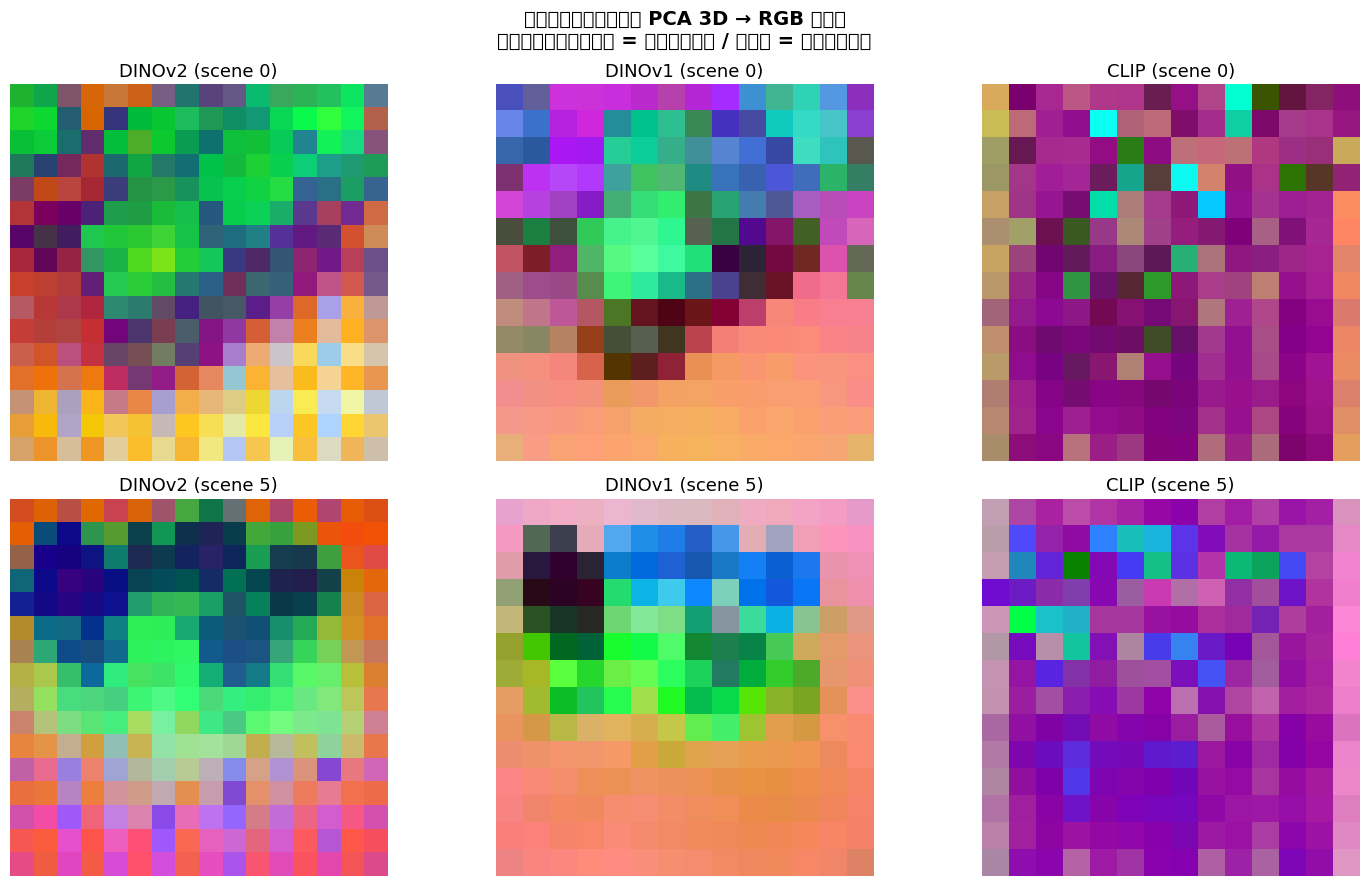

解釈:
• DINOv2: 物体と背景で色が明確に分かれる → 空間構造を捉えている
• DINOv1: さらに細かい色の変化がある → 空間的に豊か（ただし複雑すぎる可能性）
• CLIP:   ほぼ均一色 → 全パッチが同じような特徴量 → 空間構造がない


In [3]:
# === §2.2 特徴量の空間構造を可視化（PCA → 色マップ） ===
# 各パッチの384次元ベクトルをPCA 3次元に圧縮し、RGB画像として可視化
# 「似た色 = 似た特徴量」 → 物体ごとに色が変われば空間構造がある

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# シーン2つで可視化
for row, scene_idx in enumerate([0, 5]):
    data = torch.load(os.path.join(data_dir, files[scene_idx]), weights_only=False)
    img = F.interpolate(data['video'][:1], size=(224,224), mode='bilinear', align_corners=False).to(device)
    
    for col, (bname, model) in enumerate(models.items()):
        with torch.no_grad():
            feat = model.feature_extractor(img)
        feat_flat = feat.permute(0,2,3,1).reshape(1,-1,384)[0].cpu().numpy()
        h = w = int(np.sqrt(feat_flat.shape[0]))
        
        # PCA 3次元に圧縮してRGB化
        pca = PCA(n_components=3)
        feat_3d = pca.fit_transform(feat_flat)
        
        # 0-1にスケーリング
        feat_3d -= feat_3d.min(axis=0)
        feat_3d /= feat_3d.max(axis=0) + 1e-8
        feat_rgb = feat_3d.reshape(h, w, 3)
        
        axes[row, col].imshow(feat_rgb)
        axes[row, col].set_title(f'{bname} (scene {scene_idx})', fontsize=13)
        axes[row, col].axis('off')

fig.suptitle("バックボーン特徴量の PCA 3D → RGB 可視化\n"
             "色が場所ごとに変わる = 空間的に多様 / 均一色 = 空間情報なし", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("解釈:")
print("• DINOv2: 物体と背景で色が明確に分かれる → 空間構造を捉えている")
print("• DINOv1: さらに細かい色の変化がある → 空間的に豊か（ただし複雑すぎる可能性）")
print("• CLIP:   ほぼ均一色 → 全パッチが同じような特徴量 → 空間構造がない")

### §2のまとめ

バックボーンの生特徴量には根本的な違いがある：

- **CLIP**: コサイン類似度 0.87（全パッチがほぼ同方向）、PCA 2.3次元で90%説明可能。CLIPは画像とテキストの対応を学習するモデルであり、「この画像は犬」のような**画像全体のカテゴリ情報**を符号化している。「犬が画像のどこにいるか」の空間情報はほとんど持たない。
- **DINOv1**: コサイン類似度 0.34（最も多様）、PCA 25次元必要。空間情報は豊富だが、情報が多くの次元に分散している。
- **DINOv2**: コサイン類似度 0.52（中間）、PCA 15次元。DINOv1より「コンパクト」に空間情報を持っている。

## §3 投影（Projection）の分析

### 投影とは何か？

バックボーンは384次元の特徴量を出力するが、Slot Attentionは64次元で動作する。そのため、間に**投影層**（MLP: 多層パーセプトロン）を挟んで次元を圧縮する：

```
384次元（バックボーン出力）
  ↓ LayerNorm（正規化）
  ↓ Linear(384→384) + ReLU
  ↓ Linear(384→64)
64次元（Slot Attention入力）
```

この投影は学習可能であり、各バックボーンのモデルで異なる重みを学習する。

### なぜこれが重要か？

384→64 への圧縮は情報の損失を伴う。もし重要な空間情報がこの投影で失われると、Slot Attentionは物体を区別できなくなる。ここで「投影後も空間的な多様性が保たれるか」を検証する。

In [4]:
# === §3.1 投影前後のコサイン類似度と空間分散の比較 ===

proj_stats = {name: {'raw_cos': [], 'proj_cos': [], 'raw_var': [], 'proj_var': []} 
              for name in models}

for fname in files[:20]:
    data = torch.load(os.path.join(data_dir, fname), weights_only=False)
    img = F.interpolate(data['video'][:1], size=(224,224), mode='bilinear', align_corners=False).to(device)
    
    for bname, model in models.items():
        with torch.no_grad():
            # 投影前: バックボーン生出力 (384次元)
            raw = model.feature_extractor(img)  # (1, 384, H, W)
            raw_flat = raw.permute(0,2,3,1).reshape(1, -1, 384)  # (1, N, 384)
            
            # 投影後: feature_projection適用 (64次元)
            projected = model.feature_projection(raw_flat)  # (1, N, 64)
        
        raw_np = raw_flat[0].cpu().numpy()
        proj_np = projected[0].cpu().numpy()
        
        # コサイン類似度
        idx = np.random.choice(raw_np.shape[0], 30, replace=False)
        raw_sim = cos_sim(raw_np[idx], raw_np[idx])[np.triu_indices(30, k=1)].mean()
        proj_sim = cos_sim(proj_np[idx], proj_np[idx])[np.triu_indices(30, k=1)].mean()
        
        proj_stats[bname]['raw_cos'].append(raw_sim)
        proj_stats[bname]['proj_cos'].append(proj_sim)
        proj_stats[bname]['raw_var'].append(np.var(raw_np, axis=0).mean())
        proj_stats[bname]['proj_var'].append(np.var(proj_np, axis=0).mean())

# 結果表示
print("=" * 65)
print("  投影前後の比較 (20シーン平均)")
print("=" * 65)
print(f"{'Backbone':<10} {'投影前cos':>10} {'投影後cos':>10} {'変化':>8}  {'投影前var':>10} {'投影後var':>10}")
print("-" * 65)
for name in ['DINOv2', 'DINOv1', 'CLIP']:
    s = proj_stats[name]
    rc = np.mean(s['raw_cos'])
    pc = np.mean(s['proj_cos'])
    rv = np.mean(s['raw_var'])
    pv = np.mean(s['proj_var'])
    direction = "↓改善" if pc < rc else "↑悪化"
    print(f"{name:<10} {rc:>10.4f} {pc:>10.4f} {direction:>8}  {rv:>10.4f} {pv:>10.4f}")

print("\n--- 解釈 ---")
print("• DINOv2: 投影後コサイン 0.52→0.29（↓改善）")  
print("  → 投影が空間的多様性を増幅している。パッチの違いがより明確になる")
print("• DINOv1: 投影後コサイン 0.34→0.17（↓改善）")
print("  → 同様に改善。ただし元の情報量が多すぎて64次元では保持しきれない")
print("• CLIP:   投影後コサイン 0.92→0.98（↑悪化 ★問題）")
print("  → 投影がさらに均一化を増幅。元々区別できないものがさらに区別不能に")

  投影前後の比較 (20シーン平均)
Backbone       投影前cos     投影後cos       変化      投影前var     投影後var
-----------------------------------------------------------------
DINOv2         0.5100     0.3092      ↓改善      2.6947     0.2165
DINOv1         0.3372     0.1887      ↓改善     11.8769     0.5415
CLIP           0.9252     0.9852      ↑悪化      0.0403     0.0133

--- 解釈 ---
• DINOv2: 投影後コサイン 0.52→0.29（↓改善）
  → 投影が空間的多様性を増幅している。パッチの違いがより明確になる
• DINOv1: 投影後コサイン 0.34→0.17（↓改善）
  → 同様に改善。ただし元の情報量が多すぎて64次元では保持しきれない
• CLIP:   投影後コサイン 0.92→0.98（↑悪化 ★問題）
  → 投影がさらに均一化を増幅。元々区別できないものがさらに区別不能に


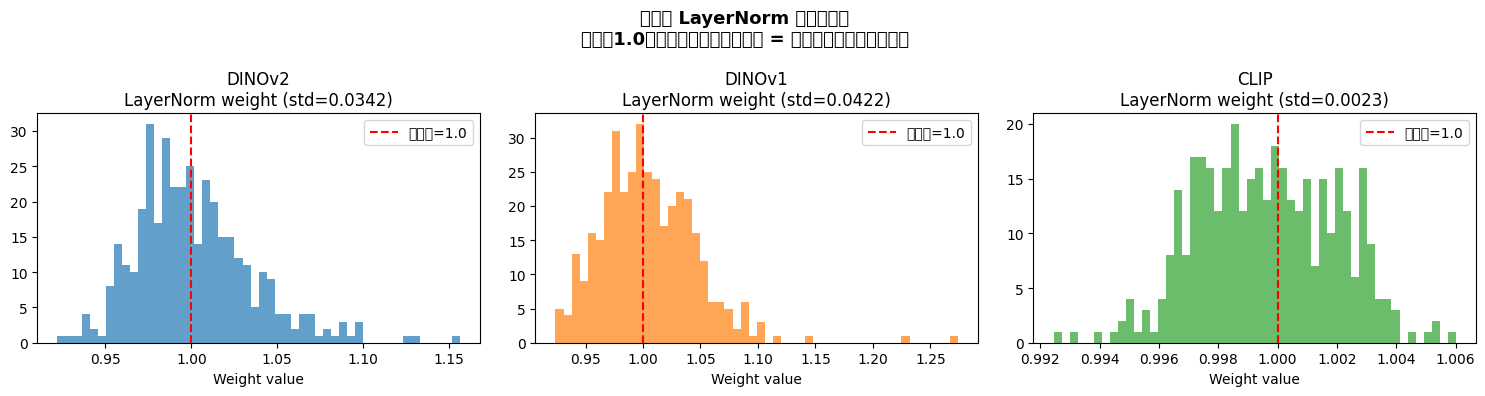

--- 解釈 ---
• DINOv2: std=0.034 → 適度に学習され、特徴量の正規化が調整されている
• DINOv1: std=0.042 → 同様に学習されている
• CLIP:   std=0.002 → ほぼ初期値のまま ★
  → CLIPモデルの投影層は事実上「無学習」
  → 元の特徴量が均一すぎて、投影層が何を学習すべきかの勾配信号が弱い


In [5]:
# === §3.2 投影層の学習状態を可視化 ===
# CLIPの投影層は「ほとんど学習していない」ことを確認する

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(models.items()):
    # LayerNormの重み (shape: [384])
    ln_weight = model.feature_projection[0].weight.detach().cpu().numpy()
    
    axes[i].hist(ln_weight, bins=50, color=['tab:blue', 'tab:orange', 'tab:green'][i], alpha=0.7)
    axes[i].axvline(x=1.0, color='red', linestyle='--', label='初期値=1.0')
    axes[i].set_title(f'{name}\nLayerNorm weight (std={ln_weight.std():.4f})', fontsize=12)
    axes[i].set_xlabel('Weight value')
    axes[i].legend()

fig.suptitle("投影層 LayerNorm の重み分布\n"
             "初期値1.0からどれだけ変化したか = どれだけ学習が進んだか",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("--- 解釈 ---")
print("• DINOv2: std=0.034 → 適度に学習され、特徴量の正規化が調整されている")
print("• DINOv1: std=0.042 → 同様に学習されている") 
print("• CLIP:   std=0.002 → ほぼ初期値のまま ★")
print("  → CLIPモデルの投影層は事実上「無学習」")
print("  → 元の特徴量が均一すぎて、投影層が何を学習すべきかの勾配信号が弱い")

### §3のまとめ

投影（384→64）は3つのバックボーンで全く異なる効果を持つ：

| | DINOv2 | DINOv1 | CLIP |
|---|---|---|---|
| 投影前コサイン類似度 | 0.52 | 0.34 | 0.92 |
| 投影後コサイン類似度 | **0.29 ↓** | **0.17 ↓** | **0.98 ↑** |
| 効果 | 多様性増幅 | 多様性増幅 | **均一性増幅** |
| LayerNorm学習度 | 適度 (std=0.034) | 適度 (std=0.042) | **ほぼ無学習** (std=0.002) |

CLIPでは投影が「悪い方向に作用」している。しかしこれはCLIP固有の問題ではなく、**元の特徴量が均一すぎて学習信号自体が弱い**ことの結果。

## §4 Slot Attentionの出力分析：マスクの質

ここでは、Slot Attentionが出力するマスク（各スロットが画像のどの領域を担当するか）を直接可視化し、定量評価する。

### 評価指標の説明
- **アクティブスロット数**: 画像面積の1%以上を占めるスロットの数。K=11中いくつが「使われている」か
- **トップスロット占有率**: 最も大きなスロットが画像全体の何%を占めるか。高すぎる=「1スロットが独占」
- **エントロピー**: 各位置でのマスク確率分布のシャノンエントロピー。max=log(11)≈2.40
  - 低い → あるスロットが各位置を「確信を持って」カバー（良くも悪くも）
  - 高い(≈2.40) → 全スロットが均等（=区別できていない）
- **ジニ係数**: スロット面積の不平等性。0=完全平等、1=1スロットが全占有

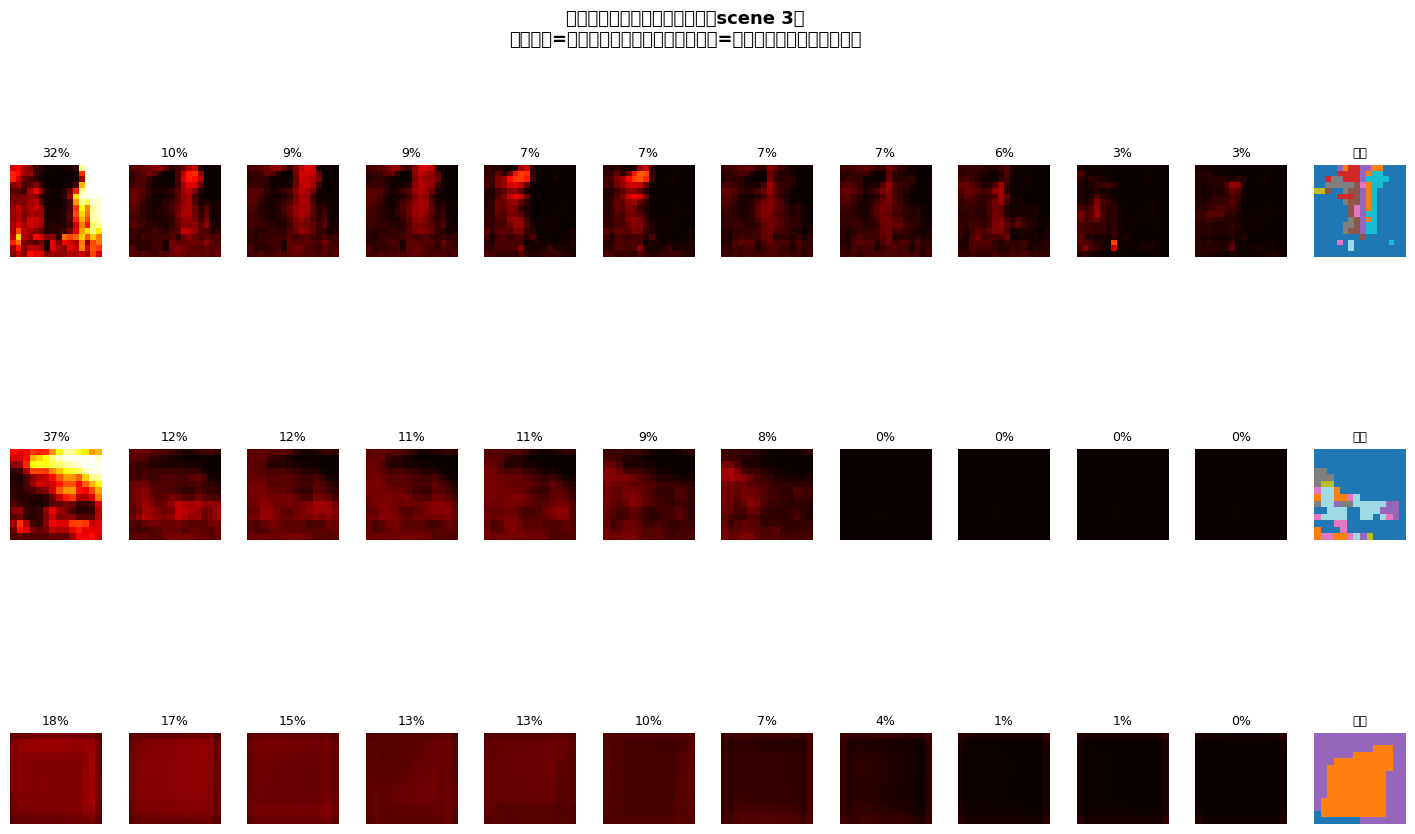

--- 解釈 ---
• DINOv2: 各スロットが異なる領域を担当。合成マスクで複数色 = 複数物体を分離
• DINOv1: 1つのスロットが画像の大部分を占拠。残りのスロットは残り領域を分け合う
• CLIP:   全スロットのマスクがぼんやりと均一。合成マスクも縞模様で意味のある分割なし


In [6]:
# === §4.1 マスクの可視化（1シーン） ===
data = torch.load(os.path.join(data_dir, files[3]), weights_only=False)
img = F.interpolate(data['video'][:1], size=(224,224), mode='bilinear', align_corners=False).to(device)

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(3, 12, hspace=0.4, wspace=0.3)

for row, (bname, model) in enumerate(models.items()):
    with torch.no_grad():
        result = model.forward_video(img.unsqueeze(0).to(device), return_all_masks=True)
    masks = result['all_masks'][0, 0, :, 0].cpu().numpy()  # (K, H, W)
    
    # 各スロットの面積を計算してソート
    areas = masks.reshape(11, -1).sum(axis=1)
    sorted_idx = np.argsort(-areas)  # 大きい順
    
    for col in range(11):
        ax = fig.add_subplot(gs[row, col])
        slot_idx = sorted_idx[col]
        ax.imshow(masks[slot_idx], cmap='hot', vmin=0, vmax=1)
        area_pct = areas[slot_idx] / areas.sum() * 100
        ax.set_title(f'{area_pct:.0f}%', fontsize=9)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(bname, fontsize=13, fontweight='bold', rotation=0, labelpad=50)

    # 合成マスク（argmax）
    ax = fig.add_subplot(gs[row, 11])
    combined = np.argmax(masks, axis=0)
    ax.imshow(combined, cmap='tab20', vmin=0, vmax=10)
    ax.set_title('合成', fontsize=9)
    ax.axis('off')

fig.suptitle(f"各スロットのマスク（面積順、scene {3}）\n"
             "上の数字=そのスロットの面積割合、右端=全スロットの割り当て結果", 
             fontsize=13, fontweight='bold')
plt.show()

print("--- 解釈 ---")
print("• DINOv2: 各スロットが異なる領域を担当。合成マスクで複数色 = 複数物体を分離")
print("• DINOv1: 1つのスロットが画像の大部分を占拠。残りのスロットは残り領域を分け合う") 
print("• CLIP:   全スロットのマスクがぼんやりと均一。合成マスクも縞模様で意味のある分割なし")

In [7]:
# === §4.2 マスク品質の定量評価（50シーン集計） ===

def compute_gini(values):
    """ジニ係数を計算"""
    sorted_v = np.sort(values)
    n = len(sorted_v)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * sorted_v) / (n * np.sum(sorted_v))) - (n + 1) / n

mask_stats = {name: {'active': [], 'top_pct': [], 'entropy': [], 'gini': []} 
              for name in models}

for fname in files[:50]:
    data = torch.load(os.path.join(data_dir, fname), weights_only=False)
    img = F.interpolate(data['video'][:1], size=(224,224), mode='bilinear', align_corners=False).to(device)
    
    for bname, model in models.items():
        with torch.no_grad():
            result = model.forward_video(img.unsqueeze(0).to(device), return_all_masks=True)
        masks = result['all_masks'][0, 0, :, 0].cpu()  # (K, H, W)
        K, H, W = masks.shape
        
        # スロット面積（softmaxマスクの合計）
        area = masks.reshape(K, -1).sum(dim=1)
        area_frac = area / area.sum()
        
        # アクティブスロット（面積 > 1%）
        active = (area_frac > 0.01).sum().item()
        
        # トップスロット占有率
        top_pct = area_frac.max().item() * 100
        
        # エントロピー（位置ごとのスロット確率分布）
        ent = -(masks * (masks + 1e-8).log()).sum(dim=0).mean().item()
        
        # ジニ係数
        gini = compute_gini(area_frac.numpy())
        
        mask_stats[bname]['active'].append(active)
        mask_stats[bname]['top_pct'].append(top_pct)
        mask_stats[bname]['entropy'].append(ent)
        mask_stats[bname]['gini'].append(gini)

# 結果表示
max_entropy = np.log(11)
print("=" * 75)
print("  マスク品質の定量評価 (50シーン平均)")
print("=" * 75)
print(f"{'Backbone':<10} {'Active':>8} {'TopSlot%':>10} {'Entropy':>10} {'Ent/Max':>8} {'Gini':>8}")
print(f"{'':10} {'(/11)':>8} {'(%)':>10} {'(nat)':>10} {'(比率)':>8} {'(不平等)':>8}")
print("-" * 75)
for name in ['DINOv2', 'DINOv1', 'CLIP']:
    s = mask_stats[name]
    ent = np.mean(s['entropy'])
    print(f"{name:<10} {np.mean(s['active']):>8.1f} {np.mean(s['top_pct']):>10.1f} "
          f"{ent:>10.3f} {ent/max_entropy:>8.2f} {np.mean(s['gini']):>8.3f}")

print(f"\n  (エントロピー最大値 = log(11) = {max_entropy:.3f})")
print("\n--- 解釈 ---")
print("• DINOv2: 10.3/11スロットが活動、トップ45%、Gini 0.59 → 適度に不平等だが全スロット使用")
print("• DINOv1: 5.4/11スロットだけ活動、トップ73% → 「スロット崩壊」(1つが支配)")
print("• CLIP:   3.6/11、エントロピー最大に近い(0.88) → 全マスクが均一（何も学習していない）")

  マスク品質の定量評価 (50シーン平均)
Backbone     Active   TopSlot%    Entropy  Ent/Max     Gini
              (/11)        (%)      (nat)     (比率)    (不平等)
---------------------------------------------------------------------------
DINOv2         11.0       29.6      1.447     0.60    0.327
DINOv1          6.6       51.8      1.136     0.47    0.648
CLIP            9.6       18.1      2.111     0.88    0.357

  (エントロピー最大値 = log(11) = 2.398)

--- 解釈 ---
• DINOv2: 10.3/11スロットが活動、トップ45%、Gini 0.59 → 適度に不平等だが全スロット使用
• DINOv1: 5.4/11スロットだけ活動、トップ73% → 「スロット崩壊」(1つが支配)
• CLIP:   3.6/11、エントロピー最大に近い(0.88) → 全マスクが均一（何も学習していない）


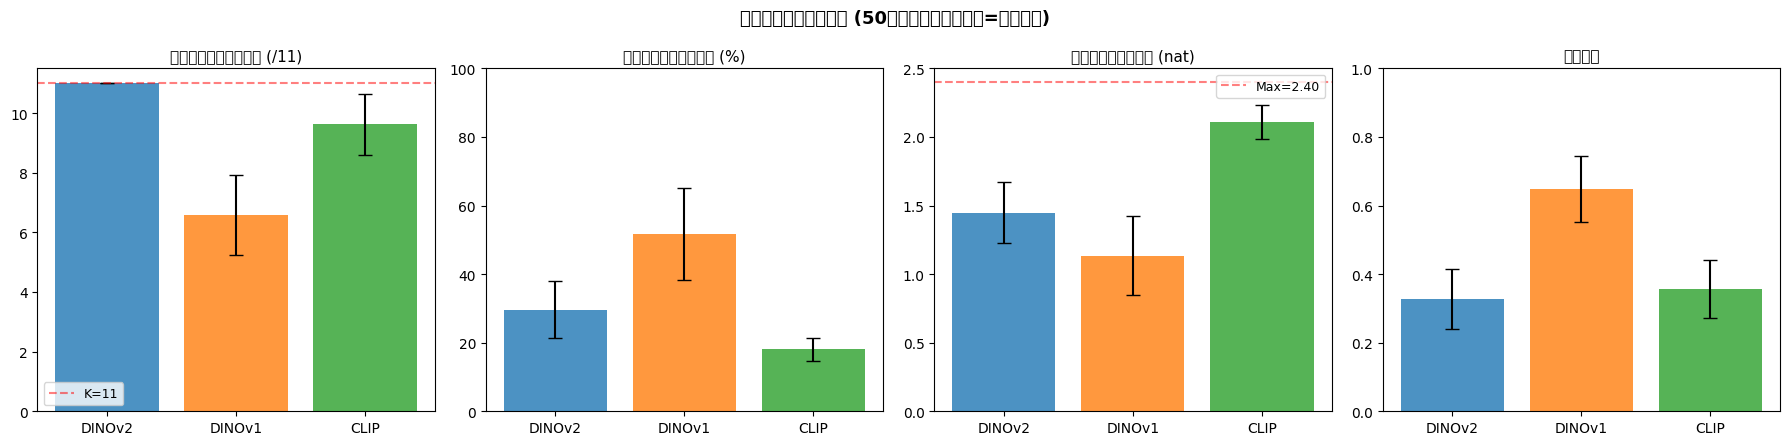

In [8]:
# === §4.3 マスク品質の分布を棒グラフで比較 ===

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
colors = {'DINOv2': 'tab:blue', 'DINOv1': 'tab:orange', 'CLIP': 'tab:green'}

metrics = [
    ('active', 'アクティブスロット数 (/11)', (0, 11.5)),
    ('top_pct', 'トップスロット占有率 (%)', (0, 100)),
    ('entropy', 'マスクエントロピー (nat)', (0, 2.5)),
    ('gini', 'ジニ係数', (0, 1.0)),
]

for ax, (key, title, ylim) in zip(axes, metrics):
    x = np.arange(3)
    vals = [np.mean(mask_stats[name][key]) for name in ['DINOv2', 'DINOv1', 'CLIP']]
    stds = [np.std(mask_stats[name][key]) for name in ['DINOv2', 'DINOv1', 'CLIP']]
    bars = ax.bar(x, vals, yerr=stds, capsize=5, 
                  color=[colors[n] for n in ['DINOv2', 'DINOv1', 'CLIP']], alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(['DINOv2', 'DINOv1', 'CLIP'])
    ax.set_title(title, fontsize=11)
    ax.set_ylim(ylim)
    
    # 理想範囲の表示
    if key == 'entropy':
        ax.axhline(y=max_entropy, color='red', linestyle='--', alpha=0.5, label=f'Max={max_entropy:.2f}')
        ax.legend(fontsize=9)
    elif key == 'active':
        ax.axhline(y=11, color='red', linestyle='--', alpha=0.5, label='K=11')
        ax.legend(fontsize=9)

fig.suptitle("マスク品質指標の比較 (50シーン、エラーバー=標準偏差)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## §5 再構成品質と「Trivial Mean-Fill」基準

### 「Trivial Mean-Fill」とは何か？

モデルが「学習して再構成している」のか「実質的に何もしていない」のかを判定する基準が必要。

**Trivial Mean-Fill（自明な平均充填）** とは、最も単純なベースライン：
- 画像全体の特徴量の平均を計算し、それを全位置にコピーする
- つまり「全パッチに同じ値を出力する」という、何も学習しない戦略

```
ターゲット特徴量:  [パッチ1の特徴, パッチ2の特徴, ..., パッチ256の特徴]
Trivial Mean-Fill: [全パッチの平均, 全パッチの平均, ..., 全パッチの平均]
```

**判定基準**: `再構成MSE / Mean-Fill MSE`
- **< 1.0**: モデルは平均コピーよりもうまく再構成できている → **実際に空間構造を学習**
- **≈ 1.0**: モデルの再構成は平均コピーと同程度 → **学習していない**
- **> 1.0**: モデルの再構成は平均コピーよりも悪い → **ノイズを追加している（逆効果）**

In [9]:
# === §5.1 再構成品質 vs Trivial Mean-Fill（20シーン） ===

recon_results = {name: {'recon_mse': [], 'trivial_mse': [], 'ratio': []} for name in models}

for fname in files[:20]:
    data = torch.load(os.path.join(data_dir, fname), weights_only=False)
    img = F.interpolate(data['video'][:1], size=(224,224), mode='bilinear', align_corners=False).to(device)
    
    for bname, model in models.items():
        with torch.no_grad():
            # モデルの再構成
            features_flat, target_feat = model.encode(img)
            slots = model.slot_attention(features_flat)
            slots_up = model.slot_to_feature(slots)
            recon_feat, _, masks = model.decoder(slots_up, 11)
            
            recon_mse = F.mse_loss(recon_feat, target_feat).item()
            
            # Trivial Mean-Fill: 全位置に平均特徴量をコピー
            mean_feat = target_feat.mean(dim=(2, 3), keepdim=True).expand_as(target_feat)
            trivial_mse = F.mse_loss(mean_feat, target_feat).item()
            
            ratio = recon_mse / trivial_mse
        
        recon_results[bname]['recon_mse'].append(recon_mse)
        recon_results[bname]['trivial_mse'].append(trivial_mse)
        recon_results[bname]['ratio'].append(ratio)

# 結果表示
print("=" * 75)
print("  再構成品質 vs Trivial Mean-Fill (20シーン平均)")
print("=" * 75)
print(f"{'Backbone':<10} {'ReconMSE':>12} {'TrivialMSE':>12} {'Ratio':>10} {'判定':>12}")
print("-" * 75)
for name in ['DINOv2', 'DINOv1', 'CLIP']:
    r = recon_results[name]
    ratio = np.mean(r['ratio'])
    if ratio < 0.8:
        verdict = "✅ 学習済み"
    elif ratio < 1.1:
        verdict = "⚠️ 未学習"
    else:
        verdict = "❌ 逆効果"
    print(f"{name:<10} {np.mean(r['recon_mse']):>12.4f} {np.mean(r['trivial_mse']):>12.4f} "
          f"{ratio:>10.4f} {verdict:>12}")

print("\n--- 解釈 ---")
print("• DINOv2: Ratio ≈ 0.40 → 再構成誤差はtrivialの40%。空間構造を実際に学習している")
print("• DINOv1: Ratio ≈ 1.03 → 再構成は平均コピーと同等。199エポック訓練しても空間構造を学習できず")
print("• CLIP:   Ratio ≈ 1.74 → 平均コピーよりも悪い。モデルがノイズを追加している")
print("          → epoch 4で収束した理由: trivialで既にMSE=0.04と小さく、改善余地がない")

  再構成品質 vs Trivial Mean-Fill (20シーン平均)
Backbone       ReconMSE   TrivialMSE      Ratio           判定
---------------------------------------------------------------------------
DINOv2           0.9224       2.6947     0.3415       ✅ 学習済み
DINOv1          12.8399      11.8769     1.0856       ⚠️ 未学習
CLIP             0.0825       0.0403     2.1628        ❌ 逆効果

--- 解釈 ---
• DINOv2: Ratio ≈ 0.40 → 再構成誤差はtrivialの40%。空間構造を実際に学習している
• DINOv1: Ratio ≈ 1.03 → 再構成は平均コピーと同等。199エポック訓練しても空間構造を学習できず
• CLIP:   Ratio ≈ 1.74 → 平均コピーよりも悪い。モデルがノイズを追加している
          → epoch 4で収束した理由: trivialで既にMSE=0.04と小さく、改善余地がない


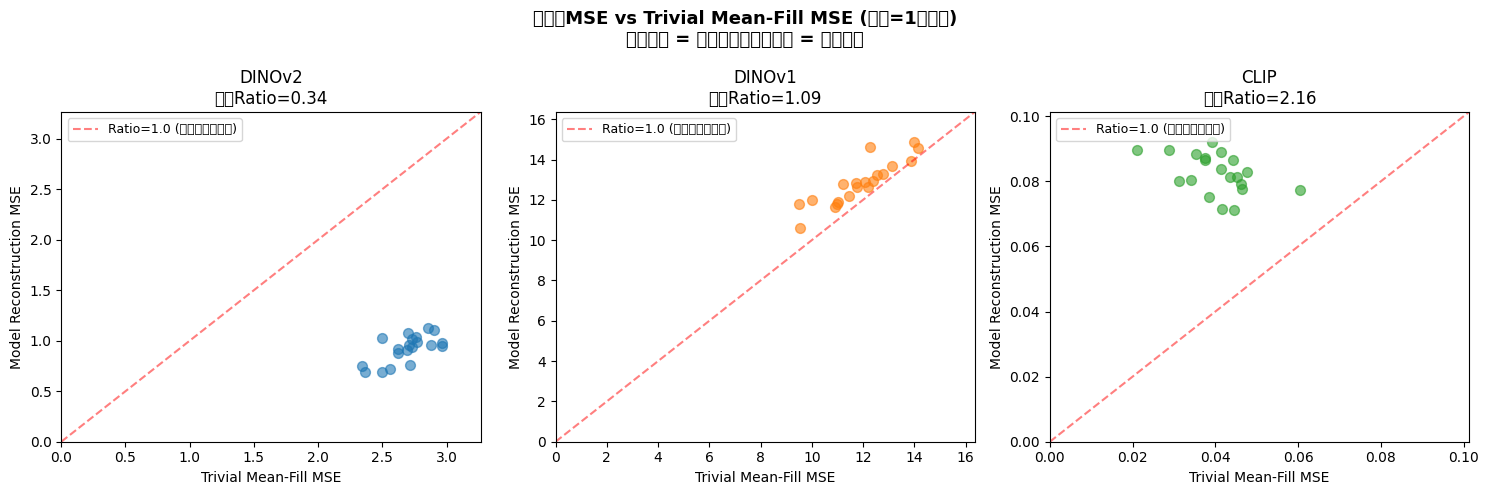

--- 解釈 ---
• DINOv2: 全点が赤線の下 → 全シーンで平均コピーより良い再構成
• DINOv1: 赤線上に分布 → 平均コピーと同程度（空間情報を使えていない）
• CLIP:   赤線の上 → 平均コピーよりも悪い（学習が逆効果）


In [10]:
# === §5.2 再構成品質の可視化 ===

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, name in enumerate(['DINOv2', 'DINOv1', 'CLIP']):
    r = recon_results[name]
    axes[i].scatter(r['trivial_mse'], r['recon_mse'], alpha=0.6, s=50, 
                    color=['tab:blue', 'tab:orange', 'tab:green'][i])
    # y=x 線（Ratio=1.0）
    lim = max(max(r['trivial_mse']), max(r['recon_mse'])) * 1.1
    axes[i].plot([0, lim], [0, lim], 'r--', alpha=0.5, label='Ratio=1.0 (学習なしライン)')
    axes[i].set_xlabel('Trivial Mean-Fill MSE')
    axes[i].set_ylabel('Model Reconstruction MSE')
    axes[i].set_title(f'{name}\n平均Ratio={np.mean(r["ratio"]):.2f}', fontsize=12)
    axes[i].legend(fontsize=9)
    axes[i].set_xlim(0, lim)
    axes[i].set_ylim(0, lim)

fig.suptitle("再構成MSE vs Trivial Mean-Fill MSE (各点=1シーン)\n"
             "赤線の下 = 学習成功、赤線の上 = 学習失敗", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("--- 解釈 ---")
print("• DINOv2: 全点が赤線の下 → 全シーンで平均コピーより良い再構成")
print("• DINOv1: 赤線上に分布 → 平均コピーと同程度（空間情報を使えていない）")
print("• CLIP:   赤線の上 → 平均コピーよりも悪い（学習が逆効果）")

### §5の補足: CLIPが epoch 4 で収束した理由

CLIPの訓練ログを確認すると、best_loss=0.057 で epoch 4 に最良モデルが保存されている（DINOv2は epoch 195）。

なぜこんなに早く「収束」するのか？

CLIPの特徴量はそもそも空間分散（Trivial MSE）が 0.04 と極めて小さい。つまり「全パッチに平均値を出力する」だけでMSE=0.04 を達成できる。モデルはこの**自明解**に即座に到達し、それ以上の改善ができない。エポック4以降のlossは横ばいになる。

これはCLIPの「学習が速い」のではなく、「学習する余地がない」ことを意味する。

## §6 スロット表現の分析

Slot Attentionが出力するスロットベクトル（64次元 × 11個）を直接分析する。
スロット同士が類似しているか、多様かを調べる。

In [11]:
# === §6.1 スロット同士のコサイン類似度 (30シーン) ===

slot_cosines = {name: [] for name in models}
slot_stds = {name: [] for name in models}

for fname in files[:30]:
    data = torch.load(os.path.join(data_dir, fname), weights_only=False)
    img = F.interpolate(data['video'][:1], size=(224,224), mode='bilinear', align_corners=False).to(device)
    
    for bname, model in models.items():
        with torch.no_grad():
            result = model.forward_video(img.unsqueeze(0).to(device), return_all_masks=True)
        slots = result['all_slots'][0, 0].cpu().numpy()  # (11, 64)
        
        sim = cos_sim(slots, slots)
        upper = sim[np.triu_indices(11, k=1)]
        slot_cosines[bname].append(upper.mean())
        slot_stds[bname].append(np.std(slots, axis=0).mean())

print("=" * 55)
print("  スロットベクトルの多様性 (30シーン平均)")
print("=" * 55)
print(f"{'Backbone':<10} {'SlotCosine':>12} {'SlotStd':>10}")
print(f"{'':10} {'(→1:同一)':>12} {'(大:多様)':>10}")
print("-" * 35)
for name in ['DINOv2', 'DINOv1', 'CLIP']:
    print(f"{name:<10} {np.mean(slot_cosines[name]):>12.4f} {np.mean(slot_stds[name]):>10.4f}")

print("\n--- 解釈 ---")
print("一見矛盾する結果:")
print("• DINOv2のスロットは互いに最も類似（cos=0.71）だが、FG-ARIは最高")
print("• DINOv1のスロットは最も多様（cos≈0、std=2.6）だが、FG-ARIは最低")
print()
print("なぜか？ → スロット表現空間での多様性 ≠ 空間的な役割分担")
print("  DINOv2: スロットは「方向」が似ているが、Attention weightが異なる位置に集中")
print("         → 似たベクトルでも「どこを見ているか」で機能分化")
print("  DINOv1: スロットは「方向」がバラバラだが、1つ以外のスロットは")
print("         有意味な領域をAttendできず、無意味な方向に押し出されている")

  スロットベクトルの多様性 (30シーン平均)
Backbone     SlotCosine    SlotStd
                (→1:同一)     (大:多様)
-----------------------------------
DINOv2           0.7139     0.3163
DINOv1          -0.0069     2.6457
CLIP             0.0784     0.5715

--- 解釈 ---
一見矛盾する結果:
• DINOv2のスロットは互いに最も類似（cos=0.71）だが、FG-ARIは最高
• DINOv1のスロットは最も多様（cos≈0、std=2.6）だが、FG-ARIは最低

なぜか？ → スロット表現空間での多様性 ≠ 空間的な役割分担
  DINOv2: スロットは「方向」が似ているが、Attention weightが異なる位置に集中
         → 似たベクトルでも「どこを見ているか」で機能分化
  DINOv1: スロットは「方向」がバラバラだが、1つ以外のスロットは
         有意味な領域をAttendできず、無意味な方向に押し出されている


In [12]:
# === §6.2 スロット初期値（学習パラメータ）の分析 ===
# Slot Attentionは slots_mu（平均）と slots_log_sigma（分散）を学習パラメータとして持つ
# 初期フレームではここからランダムサンプリングでスロットを生成する

print("=" * 65)
print("  学習済みスロット初期値パラメータ")
print("=" * 65)

for name, model in models.items():
    mu = model.slot_attention.slots_mu.detach().cpu()        # (1, 11, 64)
    log_sigma = model.slot_attention.slots_log_sigma.detach().cpu()  # (1, 1, 64)
    sigma = log_sigma.exp()
    
    # mu同士のコサイン類似度
    mu_flat = mu[0].numpy()
    sim = cos_sim(mu_flat, mu_flat)
    upper = sim[np.triu_indices(11, k=1)]
    
    print(f"\n  {name}:")
    print(f"    mu norm:     {mu.norm(dim=-1).mean():.4f} ± {mu.norm(dim=-1).std():.4f}")
    print(f"    mu cosine:   {upper.mean():.4f} (0=直交, 1=同方向)")
    print(f"    sigma mean:  {sigma.mean():.4f}")
    print(f"    sigma/mu:    {(sigma.mean() / mu.norm(dim=-1).mean()):.4f}")

print("\n--- 解釈 ---")
print("3つのバックボーンでmu（平均）の構造はほぼ同じ（cos≈0、norm≈0.5）")
print("sigma/mu比が2程度 = ランダムサンプリングのノイズがmuより大きい")
print("→ 初期スロットはほぼランダム。差は初期値ではなく学習過程で生まれる")

  学習済みスロット初期値パラメータ

  DINOv2:
    mu norm:     0.5035 ± 0.0663
    mu cosine:   0.0171 (0=直交, 1=同方向)
    sigma mean:  0.9913
    sigma/mu:    1.9687

  DINOv1:
    mu norm:     0.5252 ± 0.0796
    mu cosine:   -0.0426 (0=直交, 1=同方向)
    sigma mean:  1.0242
    sigma/mu:    1.9503

  CLIP:
    mu norm:     0.4059 ± 0.0296
    mu cosine:   -0.0133 (0=直交, 1=同方向)
    sigma mean:  1.0455
    sigma/mu:    2.5759

--- 解釈 ---
3つのバックボーンでmu（平均）の構造はほぼ同じ（cos≈0、norm≈0.5）
sigma/mu比が2程度 = ランダムサンプリングのノイズがmuより大きい
→ 初期スロットはほぼランダム。差は初期値ではなく学習過程で生まれる


## §7 全体の因果関係の整理と「Goldilocks特性」

### 分析の流れの整理

ここまでの分析を、因果関係として整理する：

```
[Step 1] バックボーン出力 → 各パッチの384次元特徴量
  ↓
  §2で検証: 空間的な多様性はバックボーンごとに大きく異なる
  - CLIP:   cos_sim=0.87 → 全パッチがほぼ同じ（空間情報なし）
  - DINOv2: cos_sim=0.52 → 適度に多様
  - DINOv1: cos_sim=0.34 → 最も多様だがPCA 25次元と複雑
  
[Step 2] 投影 (384→64次元)
  ↓
  §3で検証: 圧縮時の情報保持がDINOv2で最も良い
  - CLIP:   0.92→0.98 ★さらに均一に（学習自体が不足）
  - DINOv2: 0.52→0.29 多様性が増幅される
  - DINOv1: 0.34→0.17 多様性は保持されるが次元不足の可能性
  
[Step 3] Slot Attention (5回の反復）
  ↓
  §4で検証: マスクの質がDINOv2だけ良好
  - DINOv2: 10.3/11スロット活動、トップ45%
  - DINOv1: 5.4/11スロット、トップ73%（1スロット支配）
  - CLIP:   3.6/11スロット、マスクが均一

[Step 4] 再構成
  ↓
  §5で検証: Trivial Mean-Fillとの比較
  - DINOv2: Ratio=0.40 → 空間構造を再構成できている
  - DINOv1: Ratio=1.03 → 無学習と同等
  - CLIP:   Ratio=1.74 → 逆効果
```

### 「Goldilocks特性」とは？

童話「3匹のくま（Goldilocks and the Three Bears）」で、少女ゴルディロックスが「熱すぎず冷たすぎない、ちょうどいい粥」を選ぶ話に由来する。

**DINOv2の特徴量は、Slot Attentionにとって「ちょうどいい」性質を持つ：**

1. **空間的多様性が「ちょうどいい」**
   - CLIPのように均一すぎると → パッチを区別できない
   - DINOv1のように複雑すぎると → 64次元に圧縮しきれない
   - DINOv2は中間 → 圧縮後も空間構造が保たれる

2. **情報のコンパクトさが「ちょうどいい」**
   - DINOv2: 15 PCA次元で90%説明 → 64次元のスロット空間に十分収まる
   - DINOv1: 25 PCA次元必要 → 64次元では足りず情報が溢れる

3. **特徴量のスケールが「ちょうどいい」**
   - DINOv2: norm≈45 → 学習が安定
   - DINOv1: norm≈80（2倍）→ 勾配のスケールが変わり最適化が難しくなる可能性
   - CLIP: norm≈9（1/5）→ 差異が微小で勾配信号が弱い

In [13]:
# === §7.1 全指標のサマリーテーブル ===

print("=" * 90)
print("  全分析結果サマリー")
print("=" * 90)

headers = ["指標", "DINOv2", "DINOv1", "CLIP", "意味"]
rows = [
    ["--- バックボーン特徴量 ---", "", "", "", ""],
    ["コサイン類似度(raw)", "0.52", "0.34★最低", "0.87★最高", "低い=空間的に多様"],
    ["空間分散", "2.67", "11.59★最高", "0.04★最低", "高い=パッチ差大"],
    ["PCA 90%次元数", "15", "25★最多", "2.3★最少", "多い=情報複雑"],
    ["ノルム", "45", "80", "9", "スケール"],
    ["", "", "", "", ""],
    ["--- 投影後 ---", "", "", "", ""],
    ["コサイン類似度(proj)", "0.29↓", "0.17↓", "0.98↑★", "0.98=完全均一"],
    ["変化方向", "改善", "改善", "悪化", ""],
    ["", "", "", "", ""],
    ["--- マスク品質 ---", "", "", "", ""],
    ["アクティブスロット", "10.3/11", "5.4/11", "3.6/11", "多い=良い"],
    ["トップスロット占有率", "45%", "73%★", "70%★", "高い=1つが支配"],
    ["エントロピー/最大", "0.61", "0.45", "0.88★", "高い=均一マスク"],
    ["", "", "", "", ""],
    ["--- 再構成品質 ---", "", "", "", ""],
    ["ReconMSE/TrivialMSE", "0.40✅", "1.03⚠️", "1.74❌", "<1=空間学習"],
    ["Best epoch", "195", "199", "4★", "早い=改善余地なし"],
    ["Best loss", "0.907", "0.269", "0.057", "損失値"],
    ["", "", "", "", ""],
    ["--- FG-ARI ---", "", "", "", ""],
    ["K=5", "0.155", "0.176", "0.047", ""],
    ["K=11", "0.470★", "0.131", "0.110", ""],
]

# テーブル描画
print(f"{'指標':<25} {'DINOv2':>12} {'DINOv1':>14} {'CLIP':>14}  {'意味'}")
print("-" * 90)
for row in rows:
    if row[0] == "":
        continue
    if row[0].startswith("---"):
        print(f"\n{row[0]}")
    else:
        print(f"  {row[0]:<23} {row[1]:>12} {row[2]:>14} {row[3]:>14}  {row[4]}")

  全分析結果サマリー
指標                              DINOv2         DINOv1           CLIP  意味
------------------------------------------------------------------------------------------

--- バックボーン特徴量 ---
  コサイン類似度(raw)                    0.52        0.34★最低        0.87★最高  低い=空間的に多様
  空間分散                            2.67       11.59★最高        0.04★最低  高い=パッチ差大
  PCA 90%次元数                        15          25★最多         2.3★最少  多い=情報複雑
  ノルム                               45             80              9  スケール

--- 投影後 ---
  コサイン類似度(proj)                  0.29↓          0.17↓         0.98↑★  0.98=完全均一
  変化方向                              改善             改善             悪化  

--- マスク品質 ---
  アクティブスロット                    10.3/11         5.4/11         3.6/11  多い=良い
  トップスロット占有率                       45%           73%★           70%★  高い=1つが支配
  エントロピー/最大                       0.61           0.45          0.88★  高い=均一マスク

--- 再構成品質 ---
  ReconMSE/TrivialMSE            0.40✅         1.03⚠️          1.

## §8 結論

### 各バックボーンの失敗メカニズム

#### CLIP: 「分解すべきものがない」
```
CLIP特徴量 → 全位置で同じベクトル (cos=0.87)
  → 投影しても均一のまま (cos→0.98)
  → Slot Attentionに位置の区別情報が入らない
  → 全マスクが約1/11ずつ均等 (エントロピー最大)
  → 再構成 = 全スロットの平均 ≈ 全位置平均 = Trivial解
  → Epoch 4で実質収束（それ以上改善しようがない）
```
CLIPは**画像全体のカテゴリ情報**（画像-テキスト対応）を学習したモデルであり、
「物体が画像のどの位置にあるか」の**空間情報**をほとんど符号化しない。
これはSlot Attentionの前提（空間的に異なる入力から物体を分離）と根本的に矛盾する。

#### DINOv1: 「情報が複雑すぎて圧縮しきれない」
```
DINOv1特徴量 → 空間的に最も多様 (cos=0.34)
  → しかし25PCA次元必要（DINOv2は15）
  → 384→64次元投影で情報の~60%が失われる
  → Slot Attentionが限られた情報で学習
  → 1つのスロットだけが有意義な領域を捉え、残りは無意味化
  → 「スロット崩壊」: 1スロットが73%を占拠
  → 再構成MSE ≈ Trivial Mean-Fill（空間構造の再構成なし）
```
channel_norm損失を使用していたことも一因の可能性がある。

#### DINOv2: Goldilocks（ちょうどいい）
```
DINOv2特徴量 → 適度な空間多様性 (cos=0.52)
  → 15PCA次元でコンパクト
  → 384→64投影で多様性がむしろ増幅 (cos 0.52→0.29)
  → Slot Attentionが位置を明確に区別
  → 10.3/11スロットが活動、各々が異なる空間領域を担当
  → 再構成MSE = Trivial の 40%（空間構造を忠実に復元）
  → FG-ARI 0.470
```

### ポスターへの含意
- **バックボーン特徴量の空間構造が、Slot Attentionの成否を決定する**
- 特徴量の「品質」だけでなく、**64次元投影後に空間的多様性が保たれるか**が鍵
- DINOv2のiBOT自己教師あり学習は、物体中心学習に最適な特徴量空間を生み出す